## Preprocessing

### Imports

In [1]:
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

# Importing libraries
import pandas as pd
import numpy as np
from IPython.display import display
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import shutil
import subprocess
import zipfile
import random

### Global Definitions

In [2]:
# Global helper functions
def get_class_names():
    return [
        'Pleural Effusion'
    ]

def get_policies():
    return [
        'ones',
        'zeroes',
        'mixed'
    ]

# Global variables

# Define the class names for the medical conditions
class_names = get_class_names()

# Define the policies for dataset preparation
policies = get_policies()

# Path to the zip file
zip_path = "./chexpert.zip"

# Path to the zip file in Google Drive
zip_file_in_drive = '/content/drive/MyDrive/chexpert.zip'  # Change this to your desired location

# Path to the directory where the datasets will be extracted
data_dir = "./CheXpert-v1.0-small"

# Set the batch size
batch_size = 32

# Flag whether to modify the first layer of the model, meaning if we converted to gray scale and did not use tranformation to 3 channels
modify_first_layer = True

last_shape = 3
if modify_first_layer:
    last_shape = 1

# Set pandas display options to show all columns
pd.set_option('display.max_columns', None)

### Dataset class

In [3]:
class CheXpertDataset(Dataset):
    def __init__(self, dataframe, class_names, zip_path, transform=None):
        # Initialize the dataset with a dataframe, class names, zip path, and optional transform
        self.dataframe = dataframe
        self.class_names = class_names
        self.transform = transform  # Use this later on to resize images and pre-process if needed

    def __len__(self):
        # Return the length of the dataframe, which is the number of samples in the dataset
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get the image path from the dataframe at the given index
        img_path = self.dataframe.iloc[idx]['path']
        FOLDER = ""  # Define the folder path if needed
        img_path = FOLDER + img_path
        # Open the image and convert it to RGB
        image = Image.open(img_path).convert("RGB")
        # Get the labels for the image from the dataframe and convert them to float32
        labels = self.dataframe.iloc[idx][self.class_names].values.astype('float32')
        # Convert the labels to a torch tensor
        labels = torch.tensor(labels, dtype=torch.float32)

        # Apply the transform to the image if provided
        if self.transform:
            image = self.transform(image)

        # Return the image and labels
        return image, labels

### Preprocessing utils functions

In [4]:
def prepare_dataset(dataframe, policy, class_names):
    """
    Prepare the dataset by filtering, shuffling, and filling missing values.

    Parameters:
    - dataframe: The input DataFrame containing the dataset.
    - policy: The policy to handle uncertain labels (-1). Options are "ones", "zeroes", "mixed".
    - class_names: List of class names for the medical conditions.

    Returns:
    - x_path: Numpy array of image paths.
    - y: Numpy array of labels corresponding to the class names.
    """
    
    # Filter the dataset to include only frontal images
    dataset_df = dataframe[dataframe['Frontal/Lateral'] == 'Frontal']
    dataset_df = dataset_df.dropna(subset=['Pleural Effusion'])

    # Extract image paths and labels
    x_path = dataset_df["Path"].to_numpy()
    y_df = dataset_df[class_names]

    # Define classes to be treated as ones in the "mixed" policy
    class_ones = ['Atelectasis', 'Cardiomegaly']

    # Initialize the labels array
    y = np.empty(y_df.shape, dtype=int)

    # Define a dictionary to map policies to their corresponding actions
    policy_actions = {
        "ones": lambda cls: 1,
        "zeroes": lambda cls: 0,
        "mixed": lambda cls: 1 if cls in class_ones else 0
    }

    # Iterate over each row in the labels DataFrame
    for i, (index, row) in enumerate(y_df.iterrows()):
        labels = []
        for cls in class_names:
            curr_val = row[cls]
            if curr_val:
                curr_val = float(curr_val)
                if curr_val == 1:
                    feat_val = 1
                elif curr_val == -1:
                    feat_val = policy_actions.get(policy, lambda cls: 0)(cls)
                else:
                    feat_val = 0
            else:
                feat_val = 0
            labels.append(feat_val)
        y[i] = labels

    return x_path, y

def split_train_val(train_df, policy, class_names, test_size=0.2, random_state=42):
    """
    Split the training data into training and validation sets.

    Parameters:
    - train_df: DataFrame containing the training data.
    - policy: The policy to handle uncertain labels (-1). Options are "ones", "zeroes", "mixed".
    - class_names: List of class names for the medical conditions.
    - test_size: Proportion of the training data to include in the validation set.
    - random_state: Random seed for reproducibility.

    Returns:
    - train_df: DataFrame containing the training data.
    - val_df: DataFrame containing the validation data.
    """
    # Prepare the training dataset
    train_paths, train_labels = prepare_dataset(train_df, policy, class_names)

    # Split the training dataset into training and validation sets
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_paths, train_labels, test_size=test_size, random_state=random_state
    )

    # Create DataFrames for the training and validation sets
    train_df = pd.DataFrame({'path': train_paths})
    train_labels_df = pd.DataFrame(train_labels, columns=class_names)
    train_df = pd.concat([train_df, train_labels_df], axis=1)

    val_df = pd.DataFrame({'path': val_paths})
    val_labels_df = pd.DataFrame(val_labels, columns=class_names)
    val_df = pd.concat([val_df, val_labels_df], axis=1)

    return train_df, val_df

def prepare_test_dataset(valid_df, policy, class_names):
    """
    Prepare the test dataset (original validation set).

    Parameters:
    - valid_df: DataFrame containing the original validation data.
    - policy: The policy to handle uncertain labels (-1). Options are "ones", "zeroes", "mixed".
    - class_names: List of class names for the medical conditions.

    Returns:
    - test_df: DataFrame containing the test data.
    """
    # Prepare the test dataset
    test_paths, test_labels = prepare_dataset(valid_df, policy, class_names)

    # Create DataFrame for the test set
    test_df = pd.DataFrame({'path': test_paths})
    test_labels_df = pd.DataFrame(test_labels, columns=class_names)
    test_df = pd.concat([test_df, test_labels_df], axis=1)

    return test_df

def read_zip(zip_path='chexpert.zip'):
    """
    Read training and validation data from a zip file.

    Parameters:
    - zip_path: Path to the zip file containing the dataset.

    Returns:
    - original_train_df: DataFrame containing the original training data.
    - test_df: DataFrame containing the original validation data.
    """
    original_train_df, test_df = None, None

    # Read CSV files from the zip file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        with zip_ref.open('train.csv') as train_file:
            original_train_df = pd.read_csv(train_file)
        with zip_ref.open('valid.csv') as valid_file:
            test_df = pd.read_csv(valid_file)

    return original_train_df, test_df

def get_datasets(zip_path='chexpert.zip', train_csv='train.csv', validation_csv='validation.csv', test_csv='test.csv'):
    """
    Get the training, validation, and test datasets.

    Parameters:
    - zip_path: Path to the zip file containing the dataset.
    - train_csv: Path to the CSV file for the training data.
    - validation_csv: Path to the CSV file for the validation data.
    - test_csv: Path to the CSV file for the test data.

    Returns:
    - train_df: DataFrame containing the training data.
    - validation_df: DataFrame containing the validation data.
    - test_df: DataFrame containing the test data.
    """
    # Check if the CSV files exist
    if os.path.exists(train_csv) and os.path.exists(validation_csv) and os.path.exists(test_csv):
        # Load the datasets from the CSV files
        train_df = pd.read_csv(prefix_path + train_csv)
        validation_df = pd.read_csv(prefix_path + validation_csv)
        test_df = pd.read_csv(prefix_path + test_csv)
        print("Loaded datasets from CSV files.")
    else:
        # Read the training and validation data from the zip file
        original_train_df, test_df = read_zip(zip_path=zip_path)

        # Count the occurrences of each unique value in the "Pleural Effusion" column
        pleural_effusion_counts = original_train_df['Pleural Effusion'].value_counts()
        print(f"in original_train_df Count for each class:\n{pleural_effusion_counts}")

        policies = get_policies()
        class_names = get_class_names()

        # Select the policy to handle uncertain labels (-1)
        selected_policy = policies[0]

        # Split the original training data into separate training and validation sets
        train_df, validation_df = split_train_val(original_train_df, selected_policy, class_names)

        # Prepare the test dataset
        test_df = prepare_test_dataset(test_df, selected_policy, class_names)

        # check if the directory exists
        if not os.path.exists('dataset'):
        # Create the folder if it doesn't exist
            os.makedirs('dataset')
            print("Folder 'dataset' created successfully.")
        else:
            print("Folder 'dataset' already exists.")
        
        # Export the datasets to CSV files
        prefix_path = 'dataset/'
        train_df.to_csv(prefix_path+ train_csv, index=False)
        validation_df.to_csv(prefix_path + validation_csv, index=False)
        test_df.to_csv(prefix_path + test_csv, index=False)
        print("Exported datasets to CSV files.")

    return train_df, validation_df, test_df



In [5]:
# Helper function to apply albumentations inside torchvision pipeline
class AlbumentationsWrapper:
    def __init__(self, albumentations_transform):
        self.albumentations_transform = albumentations_transform

    def __call__(self, img):
        img = np.array(img)  # Convert PIL image to numpy
        # Apply the transform with the named argument 'image'
        img = self.albumentations_transform(image=img)["image"]
        # Convert the image to a PyTorch tensor with resizable storage
        img = torch.from_numpy(np.array(img)).type(torch.FloatTensor)
        return img

def get_transform(augment=False):
    """
    Define the transformation pipeline for the images.

    Parameters:
    - augment: Whether to apply data augmentation.

    Returns:
    - transform: Composed transformation pipeline.
    """

    transform_list = [
        A.Resize(224, 224),  # Resize images to 224x224 pixels
        A.ToGray(p=1.0, num_output_channels=1, method="pca"),  # Convert to grayscale
        A.Normalize(mean=(0.5,), std=(0.5,)),  # Normalize grayscale images
    ]

    if augment:
        transform_list.extend([
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
            A.ElasticTransform(alpha=1, sigma=50, p=0.5),  # Removed alpha_affine
            A.GaussianBlur(p=0.2),
            A.Rotate(limit=10, p=0.5),
            # Using Affine instead of ShiftScaleRotate
            A.Affine(
                scale=(0.9, 1.1),  # Scale factor range
                translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},  # Translation range
                rotate=(-10, 10),  # Rotation range in degrees
                p=0.5  # Probability of applying the transform
            ),
            # Replaced CropAndPad with Crop
            A.Crop(x_min=0, y_min=0, x_max=224, y_max=224, p=0.5),
            A.RandomCrop(height=224, width=224, p=0.5) #This will randomly crop the image, hopefully focusing on different areas
        ])

    transform_list.append(ToTensorV2())

    #Wrap the list in albumentation wrapper
    albumentations_transform = A.Compose(transform_list, p=1.0, bbox_params=None, keypoint_params=None, additional_targets=None)

    #return a wrapper to apply the transformation with additional_target
    return AlbumentationsWrapper(albumentations_transform)

def transform_dataset(df, zip_path='chexpert.zip', batch_size=16, shuffle=True, augment=False, sampler=False, num_workers=2):
    """
    Transform the dataset into DataLoader objects for given dataframe.

    Parameters:
    - df: DataFrame containing the dataset.
    - zip_path: Path to the zip file containing the images.
    - batch_size: Number of samples in each batch.
    - shuffle: Whether to shuffle the data.
    - augment: Whether to apply data augmentation.
    - sampler (bool): Whether to use a sampler for the DataLoader.
    - num_workers: Number of worker processes for data loading.

    Returns:
    - dataset: CheXpertDataset object containing the dataset.
    - loader: DataLoader object containing the dataset.
    - images: Batch of images from the DataLoader.
    - labels: Batch of labels from the DataLoader.
    """
    # Define the class names for the medical conditions
    class_names = get_class_names()

    # Get the transformation pipeline
    transformer = get_transform(augment=augment)

    # Create the dataset with the defined transformations
    dataset = CheXpertDataset(dataframe=df, class_names=class_names, zip_path=zip_path, transform=transformer)

    if sampler:
        # Calculate class weights
        class_counts = df['Pleural Effusion'].value_counts()
        class_weights = 1. / class_counts
        sample_weights = df['Pleural Effusion'].map(class_weights)
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

        # Use the sampler in the DataLoader
        loader = DataLoader(dataset, batch_size=batch_size, sampler=sampler, num_workers=num_workers, pin_memory=True)
    else:
        # Create DataLoader for the dataset
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers, pin_memory=True)

    # Verify data loading by fetching a batch of images and labels from the DataLoader
    images, labels = next(iter(loader))

    return dataset, loader, images, labels

### Download Dataset from Kaggle or Google Drive (if not available in current env)

In [6]:
# If we are in colab and we need to mount the drive
if is_colab():
  from google.colab import drive
  # Mount Google Drive
  drive.mount('/content/drive')
  print("Google Drive mounted successfully.")
else:
  print("Not in Google Colab.")

Not in Google Colab.


In [7]:
# Check if Google Drive is mounted and the zip file exists
drive_mounted = os.path.exists('/content/drive')
zip_in_drive = os.path.exists(zip_file_in_drive)

# Check if the dataset is already downloaded locally, if not download it
print(f"Checking if dataset zip file exists at {zip_path}")
if not os.path.exists(zip_path):
    # Use the zip file from Google Drive if available, otherwise download
    print("Dataset zip file not found locally, searching in drive if connected.")
    if drive_mounted and zip_in_drive:
        print("Using dataset from Google Drive.")
        zip_path = zip_file_in_drive  # Update zip_path to use the Drive location
    else:
        print("Downloading the dataset...")
        # Check if kaggle is installed
        try:
            subprocess.run(["kaggle", "--version"], check=True)
            print("Kaggle is already installed.")
        except subprocess.CalledProcessError:
            print("Kaggle is not installed. Installing kaggle...")
            %pip install kaggle

        # Check if the kaggle.json file exists in the destination
        kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')
        if not os.path.exists('kaggle.json') and not os.path.exists(kaggle_json_path):
            # Move kaggle.json to ~/.kaggle
            os.makedirs(os.path.dirname(kaggle_json_path), exist_ok=True)
            shutil.move('kaggle.json', kaggle_json_path)
            # Set permissions
            os.chmod(kaggle_json_path, 0o600)
        else:
            print("kaggle.json already exists in the destination.")

        # Download the dataset from Kaggle
        subprocess.run(["kaggle", "datasets", "download", "-d", "ashery/chexpert"], check=True)
        print("Dataset was downloaded from Kaggle.")

        if drive_mounted:
            print("Saving dataset to Google Drive for future use.")
            shutil.copy(zip_path, zip_file_in_drive)
            print(f"Dataset saved to {zip_file_in_drive}")

else:
    print("Dataset already downloaded.")

Checking if dataset zip file exists at ./chexpert.zip
Dataset already downloaded.


### Extract the Zip File to Improve Performance

In [8]:
# Check if the dataset is already extracted, if not extract it
if not os.path.exists(data_dir):
    print("Extracting the dataset...")
    #unzip
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    #list files in the extracted dir
    os.listdir(data_dir)
else:
    print("Dataset already extracted.")

Dataset already extracted.


### Load train, validtion and test datasets

In [9]:
# Load the datasets
train_df, validation_df, test_df = get_datasets(zip_path)

if train_df is None or validation_df is None or test_df is None:
    print("Error loading the datasets.")
else:
    print("Datasets loaded successfully.")

in original_train_df Count for each class:
Pleural Effusion
 1.0    86187
 0.0    35396
-1.0    11628
Name: count, dtype: int64
Folder 'dataset' already exists.
Exported datasets to CSV files.
Datasets loaded successfully.


### Peak into training dataset

In [10]:
# Print some information about the train DataFrame
display(train_df.head())
print("Number of rows and columns in the train DataFrame:", train_df.shape)
# Print the column names and their data types
print("Column names and data types:")
print(train_df.dtypes)

# Count the occurrences of each unique value in the "Pleural Effusion" column
pleural_effusion_counts = train_df['Pleural Effusion'].value_counts()

# Print the counts for each class
print(f"Count for each class:\n{pleural_effusion_counts}")

,path,Pleural Effusion
0,CheXpert-v1.0-small/train/patient16646/study1/...,1
1,CheXpert-v1.0-small/train/patient10056/study9/...,1
2,CheXpert-v1.0-small/train/patient42372/study4/...,1
3,CheXpert-v1.0-small/train/patient45046/study5/...,1
4,CheXpert-v1.0-small/train/patient05198/study2/...,0


Number of rows and columns in the train DataFrame: (89420, 2)
Column names and data types:
path                object
Pleural Effusion     int64
dtype: object
Count for each class:
Pleural Effusion
1    69302
0    20118
Name: count, dtype: int64


### Peak into the validation dataset

In [11]:
# Print some information about the validtion DataFrame
# Set pandas display options to show all columns
display(validation_df.head())
print("Number of rows and columns in the validation DataFrame:", validation_df.shape)
# Print the column names and their data types
print("Column names and data types:")
print(validation_df.dtypes)

# Count the occurrences of each unique value in the "Pleural Effusion" column
pleural_effusion_counts = validation_df['Pleural Effusion'].value_counts()

# Print the counts for each class
print(f"Count for each class:\n{pleural_effusion_counts}")

,path,Pleural Effusion
0,CheXpert-v1.0-small/train/patient48924/study2/...,1
1,CheXpert-v1.0-small/train/patient38687/study1/...,1
2,CheXpert-v1.0-small/train/patient03187/study2/...,1
3,CheXpert-v1.0-small/train/patient37033/study15...,1
4,CheXpert-v1.0-small/train/patient25492/study1/...,0


Number of rows and columns in the validation DataFrame: (22356, 2)
Column names and data types:
path                object
Pleural Effusion     int64
dtype: object
Count for each class:
Pleural Effusion
1    17175
0     5181
Name: count, dtype: int64


### Peak into the test dataset

In [12]:
# Print some information about the train DataFrame
# Set pandas display options to show all columns
display(test_df.head())
print("Number of rows and columns in the test DataFrame:", test_df.shape)
# Print the column names and their data types
print("Column names and data types:")
print(test_df.dtypes)


# Count the occurrences of each unique value in the "Pleural Effusion" column
pleural_effusion_counts = test_df['Pleural Effusion'].value_counts()

# Print the counts for each class
print(f"Count for each class:\n{pleural_effusion_counts}")

,path,Pleural Effusion
0,CheXpert-v1.0-small/valid/patient64541/study1/...,0
1,CheXpert-v1.0-small/valid/patient64542/study1/...,0
2,CheXpert-v1.0-small/valid/patient64543/study1/...,0
3,CheXpert-v1.0-small/valid/patient64544/study1/...,0
4,CheXpert-v1.0-small/valid/patient64545/study1/...,1


Number of rows and columns in the test DataFrame: (202, 2)
Column names and data types:
path                object
Pleural Effusion     int64
dtype: object
Count for each class:
Pleural Effusion
0    138
1     64
Name: count, dtype: int64


### Dataset Preparation for PyTorch (Using DataLoaders)

In [13]:
num_of_workers = 0
if is_colab():
    num_of_workers = 4

# Transform the training, validation, and test dataset
train_dataset, train_loader, train_images, train_labels = transform_dataset(train_df, zip_path, batch_size=batch_size, shuffle=True, augment=True, sampler=True, num_workers=num_of_workers)
validtion_dataset, validation_loader, validtion_images, validtion_labels = transform_dataset(validation_df, zip_path, batch_size=batch_size, shuffle=False, augment=False, num_workers=num_of_workers)
test_dataset, test_loader, test_images, test_labels = transform_dataset(test_df, zip_path, batch_size=batch_size, shuffle=False, augment=False, num_workers=num_of_workers)

C:\Users\carro\AppData\Local\Temp\ipykernel_9592\2502598636.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = torch.from_numpy(np.array(img)).type(torch.FloatTensor)
C:\Users\carro\AppData\Local\Temp\ipykernel_9592\2502598636.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = torch.from_numpy(np.array(img)).type(torch.FloatTensor)
C:\Users\carro\AppData\Local\Temp\ipykernel_9592\2502598636.py:11: DeprecationWarning: __array__ implementation doesn't accept a

### Visualising example

Image 11, Label: 0.0
Original shape: torch.Size([1, 224, 224]), New shape: (224, 224, 1)
Example image:


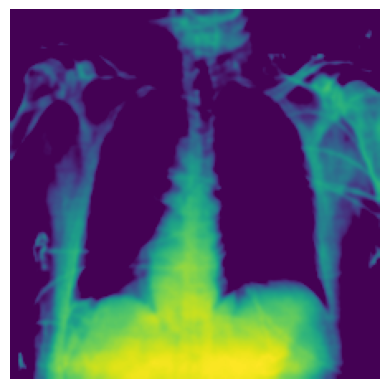

Image 8, Label: 0.0
Original shape: torch.Size([1, 224, 224]), New shape: (224, 224, 1)
Example image:


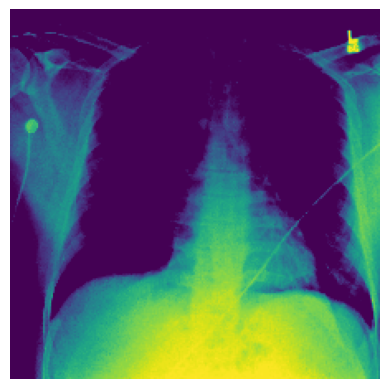

Image 22, Label: 1.0
Original shape: torch.Size([1, 224, 224]), New shape: (224, 224, 1)
Example image:


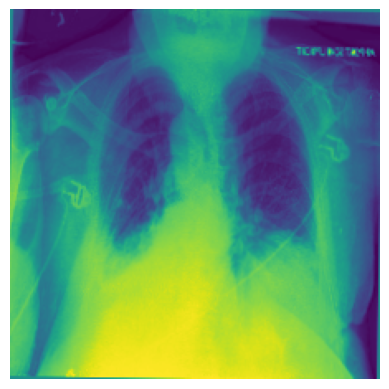

Image 3, Label: 1.0
Original shape: torch.Size([1, 224, 224]), New shape: (224, 224, 1)
Example image:


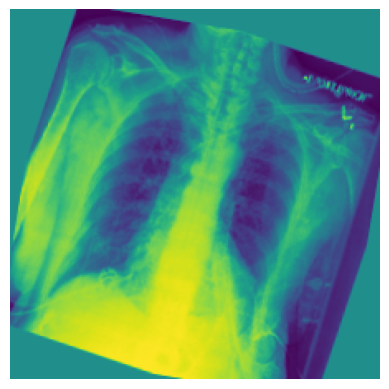

Image 7, Label: 0.0
Original shape: torch.Size([1, 224, 224]), New shape: (224, 224, 1)
Example image:


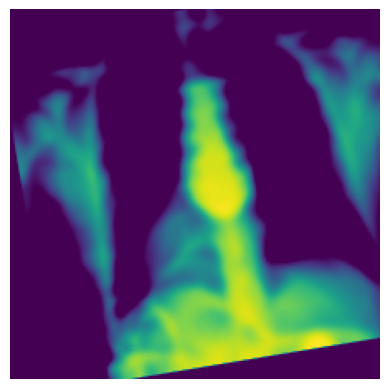

In [14]:
# Select 5 random images from the dataset
random_indices = random.sample(range(len(train_images)), 5)

for i in random_indices:
    image = train_images[i]
    label = train_labels[i]
    print(f"Image {i}, Label: {label.item()}")
    original_shape = image.shape
    image = image.permute(1, 2, 0).numpy()  # Change shape to (224, 224, last_shape)
    new_shape = image.shape
    print(f"Original shape: {original_shape}, New shape: {new_shape}")
    # Check the shape of the image to ensure it is (224, 224, last_shape)
    assert new_shape == (224, 224, last_shape), f"Expected shape (224, 224, {last_shape}), but got {image.shape}"

    # Denormalize the image for visualization
    image = (image * 0.5) + 0.5

    # Plot the image
    print("Example image:")
    plt.imshow(image)
    plt.axis('off')  # Hide axes
    plt.show()

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import accuracy_score, roc_auc_score

# Use Metal (Apple Silicon GPU) if available, otherwise CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Initialize ResNet18 from scratch (weights=None)
model = models.resnet18(weights=None)

# Modify for 1-channel input (Grayscale X-rays)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify for 1-class output (Pleural Effusion)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1)

model = model.to(device)

# Define Loss and Optimizer
# Using BCEWithLogitsLoss because the output is a raw logit
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Training and Validation Functions ---

def train_model(model, train_loader, validation_loader, epochs=30):
    print(f"Starting Training for {epochs} epochs...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            # Ensure labels are float and flattened to [batch_size]
            labels = labels.float().to(device).view(-1)
            
            optimizer.zero_grad()
            
            # Ensure outputs are flattened to [batch_size]
            outputs = model(images).view(-1)
            
            # Now [32] matches [32]
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
        
        validate_model(model, validation_loader)

def validate_model(model, loader, mode="Validation"):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().view(-1) # Flatten labels
            
            outputs = model(images).view(-1) # Flatten outputs
            probs = torch.sigmoid(outputs)
            
            preds = (probs > 0.5).int().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_preds)
    print(f"{mode} Accuracy: {acc:.4f} | {mode} AUC: {auc:.4f}")
    return auc

# Start Training
train_model(model, train_loader, validation_loader, epochs=30)

Starting Training for 30 epochs...


/Users/kumkum/Desktop/Desktop - Kumkum’s MacBook Air/Explainable AI/Project 2/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/hr/lb111yvs4td5g6d1_43wx61c0000gn/T/ipykernel_71368/4071657702.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = torch.from_numpy(np.array(img)).type(torch.FloatTensor)


Epoch 1/30, Loss: 0.4529
Validation Accuracy: 0.8680 | Validation AUC: 0.8357


/Users/kumkum/Desktop/Desktop - Kumkum’s MacBook Air/Explainable AI/Project 2/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/hr/lb111yvs4td5g6d1_43wx61c0000gn/T/ipykernel_71368/4071657702.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = torch.from_numpy(np.array(img)).type(torch.FloatTensor)


Epoch 2/30, Loss: 0.3856
Validation Accuracy: 0.8788 | Validation AUC: 0.8588


...

Epoch 28/30, Loss: 0.2747
Validation Accuracy: 0.8711 | Validation AUC: 0.8783


/Users/kumkum/Desktop/Desktop - Kumkum’s MacBook Air/Explainable AI/Project 2/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/hr/lb111yvs4td5g6d1_43wx61c0000gn/T/ipykernel_71368/4071657702.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = torch.from_numpy(np.array(img)).type(torch.FloatTensor)


Epoch 29/30, Loss: 0.2715
Validation Accuracy: 0.8637 | Validation AUC: 0.8776


/Users/kumkum/Desktop/Desktop - Kumkum’s MacBook Air/Explainable AI/Project 2/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/hr/lb111yvs4td5g6d1_43wx61c0000gn/T/ipykernel_71368/4071657702.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = torch.from_numpy(np.array(img)).type(torch.FloatTensor)


Epoch 30/30, Loss: 0.2736
Validation Accuracy: 0.8674 | Validation AUC: 0.8788


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def test_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    print("Running evaluation on test set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().view(-1) 

            outputs = model(images).view(-1)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int().cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # --- CALCULATE METRICS ---
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_preds)

    print("-" * 30)
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Precision:      {prec:.4f}")
    print(f"Recall:         {rec:.4f}")
    print(f"F1 Score:       {f1:.4f}")
    print(f"Test AUC Score: {auc:.4f}")
    print("-" * 30)
    
    return acc, prec, rec, f1, auc

test_model(model, test_loader)

# 2. Save the weights
# Use a clear name so you remember it's the one you trained from scratch
torch.save(model.state_dict(), "resnet_pleural_effusion_scratch.pth")
print("Model weights successfully saved for the Explainable stage.")

Running evaluation on test set...


/Users/kumkum/Desktop/Desktop - Kumkum’s MacBook Air/Explainable AI/Project 2/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/hr/lb111yvs4td5g6d1_43wx61c0000gn/T/ipykernel_71368/4071657702.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = torch.from_numpy(np.array(img)).type(torch.FloatTensor)


------------------------------
Test Accuracy:  0.8218
Precision:      0.6892
Recall:         0.7969
F1 Score:       0.7391
Test AUC Score: 0.8151
------------------------------
Model weights successfully saved for the Explainable stage.


In [ ]:
import torch

data = torch.load("resnet_pleural_effusion_scratch.pth")

print(data)

# Evaluation

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch.nn as nn
from torchvision import models
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
# output of evaluation plots
OUTPUT_DIR = "evaluation_outputs/"
WEIGHTS_PATH = "resnet_pleural_effusion_scratch.pth"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Use Metal (Apple Silicon GPU) if available, otherwise CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [15]:
model = models.resnet18(weights=None)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1)

state_dict = torch.load(WEIGHTS_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Model loaded.")

C:\Users\carro\AppData\Local\Temp\ipykernel_9592\698653798.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(WEIGHTS_PATH, map_location=device)


Model loaded.


In [16]:
all_probs  = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images).view(-1)
        probs   = torch.sigmoid(outputs).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.float().view(-1).numpy().tolist())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = (all_probs > 0.5).astype(int)

C:\Users\carro\AppData\Local\Temp\ipykernel_9592\2502598636.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = torch.from_numpy(np.array(img)).type(torch.FloatTensor)
C:\Users\carro\AppData\Local\Temp\ipykernel_9592\2502598636.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = torch.from_numpy(np.array(img)).type(torch.FloatTensor)
C:\Users\carro\AppData\Local\Temp\ipykernel_9592\2502598636.py:11: DeprecationWarning: __array__ implementation doesn't accept a

In [18]:
# Calculate AUC-ROC and AUC-PR scores
auc_roc = roc_auc_score(all_labels, all_probs)
auc_pr  = average_precision_score(all_labels, all_probs)
print(f"AUC-ROC : {auc_roc:.4f}")
print(f"AUC-PR  : {auc_pr:.4f}")
print(classification_report(all_labels, all_preds,
      target_names=["No Effusion", "Pleural Effusion"]))

AUC-ROC : 0.8965
AUC-PR  : 0.8286
                  precision    recall  f1-score   support

     No Effusion       0.90      0.80      0.85       138
Pleural Effusion       0.65      0.81      0.72        64

        accuracy                           0.80       202
       macro avg       0.78      0.80      0.78       202
    weighted avg       0.82      0.80      0.81       202



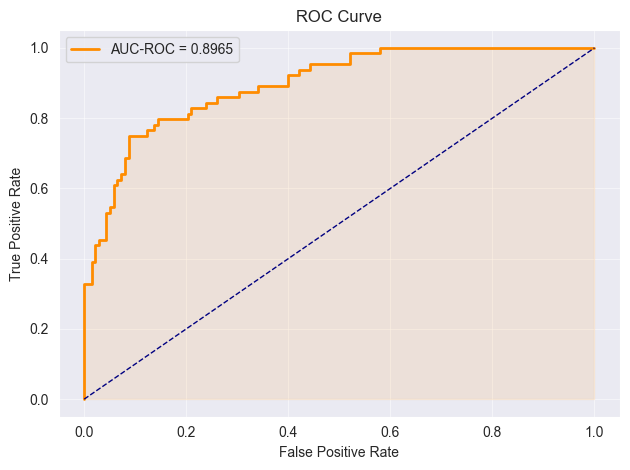

In [19]:
# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC-ROC = {auc_roc:.4f}")
plt.plot([0,1],[0,1],"--",color="navy",lw=1)
plt.fill_between(fpr, tpr, alpha=0.1, color="darkorange")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(); plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=150); plt.show()

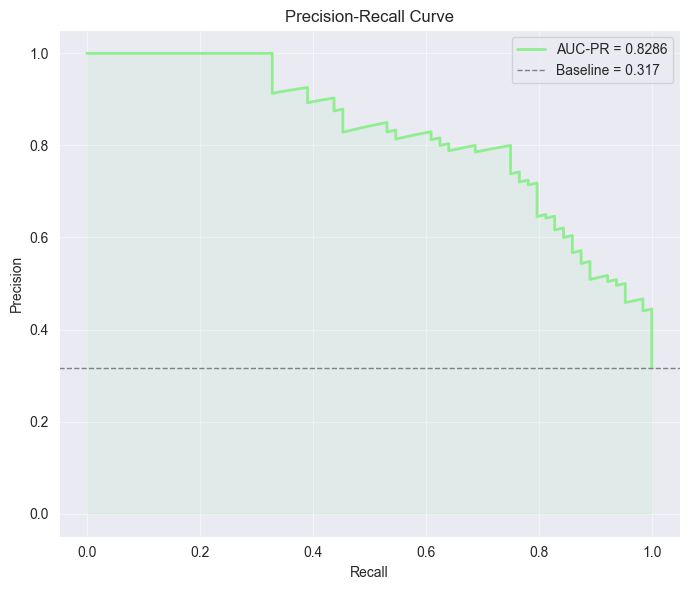

In [20]:
# PR curve
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
baseline = all_labels.mean()
plt.figure(figsize=(7,6))
plt.plot(recall_vals, precision_vals, color="lightgreen", lw=2, label=f"AUC-PR = {auc_pr:.4f}")
plt.axhline(y=baseline, color="gray", lw=1, linestyle="--", label=f"Baseline = {baseline:.3f}")
plt.fill_between(recall_vals, precision_vals, alpha=0.1, color="lightgreen")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve"); plt.legend(); plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pr_curve.png", dpi=150); plt.show()

Sensitivity: 0.8125 | Specificity: 0.7971


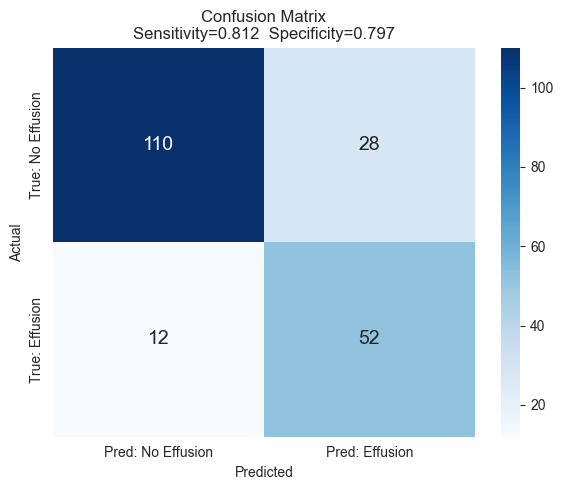

In [21]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity  = tn / (tn + fp)
print(f"Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}")
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No Effusion","Pred: Effusion"],
            yticklabels=["True: No Effusion","True: Effusion"],
            annot_kws={"size":14})
plt.title(f"Confusion Matrix\nSensitivity={sensitivity:.3f}  Specificity={specificity:.3f}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150); plt.show()